In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Ready to start!")

Ready to start!


In [2]:
# Define the column names for the data
# Based on the C-MAPSS dataset documentation
operational_settings = ['setting_1', 'setting_2', 'setting_3']
sensor_measurements = [f'sensor_{i}' for i in range(1, 22)]
column_names = ['unit_nr', 'time_cycle'] + operational_settings + sensor_measurements

# Load the training data from the text file
# sep=' ' means data is separated by spaces, header=None means there's no header row
train_df = pd.read_csv('./data/train_FD001.txt', sep=' ', header=None)

# The file has extra empty columns at the end, let's drop them
train_df.drop(columns=[26, 27], inplace=True)

# Assign the column names we defined
train_df.columns = column_names

# Show the first 5 rows to verify
train_df.head()

,unit_nr,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# Find the maximum cycle for each engine unit
max_cycles = train_df.groupby('unit_nr')['time_cycle'].max()

# Merge this max_cycle information back into the original dataframe
train_df = train_df.merge(max_cycles.to_frame(name='max_cycle'), left_on='unit_nr', right_index=True)

# Calculate the RUL for each row
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycle']

# Drop the 'max_cycle' column as we don't need it anymore
train_df.drop(columns=['max_cycle'], inplace=True)

# --- THIS IS THE CRUCIAL NEW LINE ---
# Clip the RUL at 125 cycles. This simplifies the problem for the model.
train_df['RUL'] = train_df['RUL'].clip(upper=125)


# Show the last 5 rows of engine #1 to see the RUL counting down
print("RUL for the end of Engine 1's life:")
print(train_df[train_df['unit_nr'] == 1].tail())

# Show the first 5 rows of engine #1 to see the clipped RUL
print("\nRUL for the beginning of Engine 1's life:")
print(train_df[train_df['unit_nr'] == 1].head())

RUL for the end of Engine 1's life:
     unit_nr  time_cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
187        1         188    -0.0067     0.0003      100.0    518.67    643.75   
188        1         189    -0.0006     0.0002      100.0    518.67    644.18   
189        1         190    -0.0027     0.0001      100.0    518.67    643.64   
190        1         191    -0.0000    -0.0004      100.0    518.67    643.34   
191        1         192     0.0009    -0.0000      100.0    518.67    643.54   

     sensor_3  sensor_4  sensor_5  ...  sensor_13  sensor_14  sensor_15  \
187   1602.38   1422.78     14.62  ...    2388.23    8117.69     8.5207   
188   1596.17   1428.01     14.62  ...    2388.33    8117.51     8.5183   
189   1599.22   1425.95     14.62  ...    2388.35    8112.58     8.5223   
190   1602.36   1425.77     14.62  ...    2388.30    8114.61     8.5174   
191   1601.41   1427.20     14.62  ...    2388.32    8110.93     8.5113   

     sensor_16  sensor_17 

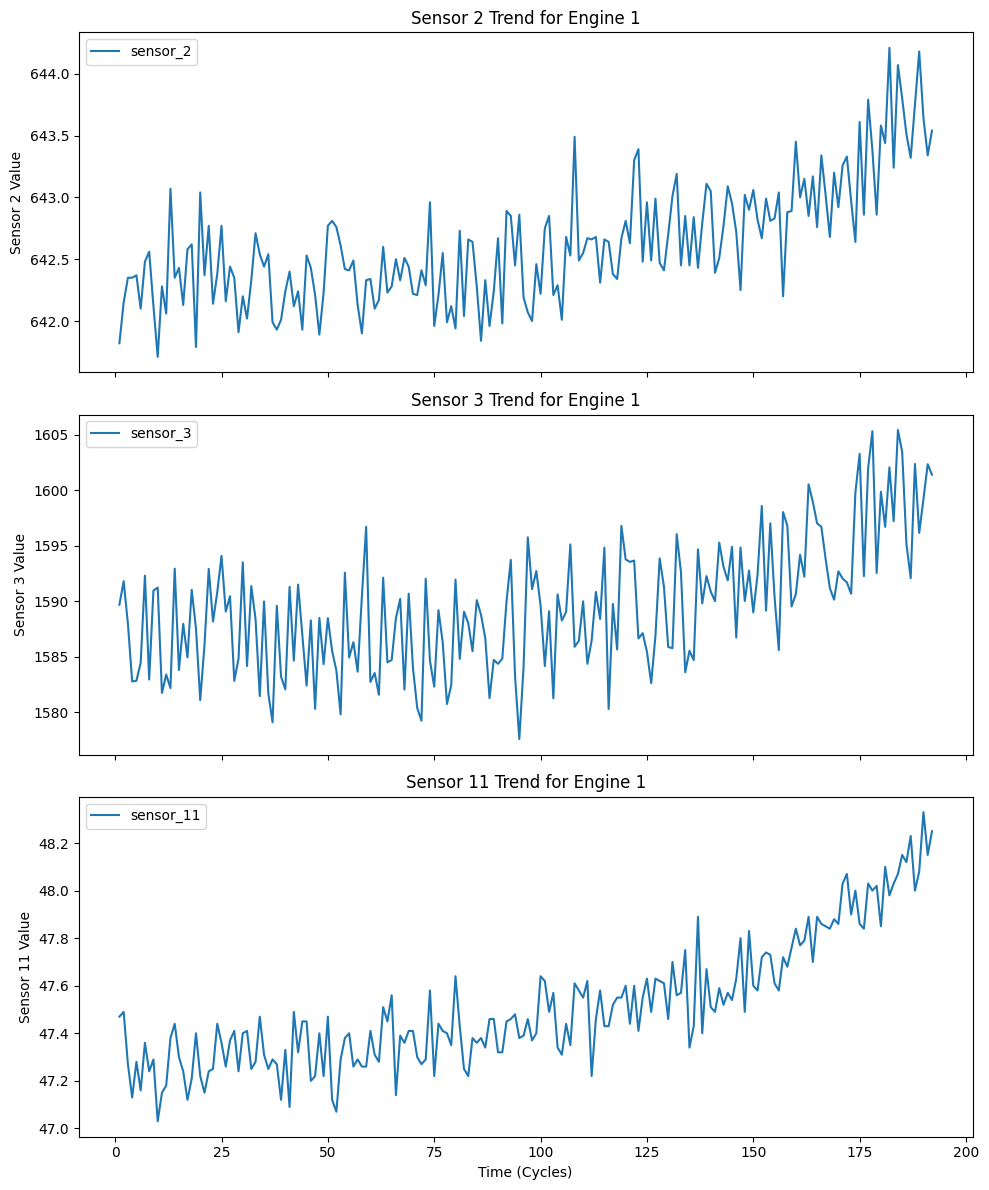

In [4]:
# We'll work with the data for a single engine unit to start
engine_1_df = train_df[train_df['unit_nr'] == 1]

# Plot a few of the sensor measurements over the time cycles
# This helps us see if there is a trend
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Sensor 2
engine_1_df.plot(x='time_cycle', y='sensor_2', ax=axes[0], title='Sensor 2 Trend for Engine 1')
axes[0].set_ylabel('Sensor 2 Value')

# Sensor 3
engine_1_df.plot(x='time_cycle', y='sensor_3', ax=axes[1], title='Sensor 3 Trend for Engine 1')
axes[1].set_ylabel('Sensor 3 Value')

# Sensor 4
engine_1_df.plot(x='time_cycle', y='sensor_11', ax=axes[2], title='Sensor 11 Trend for Engine 1')
axes[2].set_xlabel('Time (Cycles)')
axes[2].set_ylabel('Sensor 11 Value')

plt.tight_layout()
plt.show()

In [5]:
print("--- Finding constant sensors (Robust method) ---")

# Let's calculate the standard deviation for each sensor
sensor_std = train_df[sensor_measurements].std()

# Instead of checking for exactly 0, we check for a value smaller than a tiny threshold
# This handles floating point inaccuracies.
threshold = 1e-9 
constant_sensors = sensor_std[sensor_std < threshold].index.tolist()

print(f"\nFound {len(constant_sensors)} sensors with near-zero variation:")
print(constant_sensors)


# --- Now we proceed as before, but with the correctly identified list ---
print("\nDropping these sensors from our data...")
train_df.drop(columns=constant_sensors, inplace=True)

# We also need to remove them from our master list of sensor names
# This is very important for the next steps!
sensor_measurements = [s for s in sensor_measurements if s not in constant_sensors]

print(f"\nSuccess! We now have {len(sensor_measurements)} useful sensors remaining.")
print("The remaining sensors are:", sensor_measurements)

--- Finding constant sensors (Robust method) ---

Found 6 sensors with near-zero variation:
['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Dropping these sensors from our data...

Success! We now have 15 useful sensors remaining.
The remaining sensors are: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


C:\Users\ANISH\AppData\Local\Temp\ipykernel_20156\3826970985.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[f'{sensor_to_smooth}_smoothed'].fillna(method='bfill', inplace=True)
C:\Users\ANISH\AppData\Local\Temp\ipykernel_20156\3826970985.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[f'{sensor_to_smooth}_smoothed'].fillna(method='bfill', inplace=True)


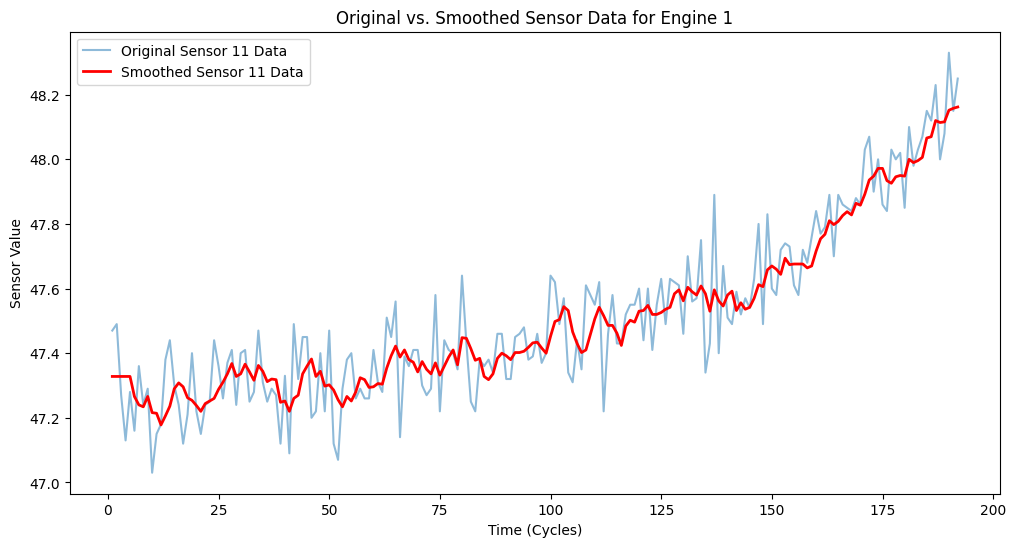

In [6]:
# A window size is the number of past cycles to average over.
# It's a hyperparameter we can tune, but 5 is a good starting point.
window_size = 5

# Let's pick a sensor with a good trend, like sensor 11
sensor_to_smooth = 'sensor_11'

# Calculate the rolling average
# .rolling(window=window_size) creates the window
# .mean() calculates the average within that window
rolling_avg = train_df.groupby('unit_nr')[sensor_to_smooth].rolling(window=window_size).mean()

# The result is a Series with a multi-level index. We need to drop the unit_nr level to align it back.
rolling_avg = rolling_avg.reset_index(level=0, drop=True)

# Let's create a new column for this smoothed feature
train_df[f'{sensor_to_smooth}_smoothed'] = rolling_avg

# Fill the initial NaN values (the first few rows where the window isn't full yet)
# We can use backfill, which uses the next valid observation to fill the gap.
train_df[f'{sensor_to_smooth}_smoothed'].fillna(method='bfill', inplace=True)


# --- Let's Visualize the difference ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the original sensor data for engine 1
ax.plot(train_df[train_df['unit_nr'] == 1]['time_cycle'], 
        train_df[train_df['unit_nr'] == 1][sensor_to_smooth], 
        label='Original Sensor 11 Data', alpha=0.5)

# Plot the smoothed sensor data for engine 1
ax.plot(train_df[train_df['unit_nr'] == 1]['time_cycle'], 
        train_df[train_df['unit_nr'] == 1][f'{sensor_to_smooth}_smoothed'], 
        label='Smoothed Sensor 11 Data', color='red', linewidth=2)

ax.set_title('Original vs. Smoothed Sensor Data for Engine 1')
ax.set_xlabel('Time (Cycles)')
ax.set_ylabel('Sensor Value')
ax.legend()
plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Our FINAL set of features includes the settings and the useful sensors
features_to_scale = operational_settings + sensor_measurements 

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data AND transform it
train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])

print("Scaler has been trained on operational settings and sensors.")
train_df.head()

Scaler has been trained on operational settings and sensors.


,unit_nr,time_cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL,sensor_11_smoothed
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,1.0,0.726248,...,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125,47.328
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,1.0,0.628019,...,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125,47.328
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,1.0,0.710145,...,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125,47.328
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,1.0,0.740741,...,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125,47.328
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,1.0,0.668277,...,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125,47.328


In [8]:
# --- Load the Test Data ---
test_df = pd.read_csv('data/test_FD001.txt', sep=' ', header=None)
test_df.drop(columns=[26, 27], inplace=True)
test_df.columns = column_names

# --- Load the Ground Truth RUL ---
truth_df = pd.read_csv('data/RUL_FD001.txt', sep=' ', header=None)
truth_df.drop(columns=[1], inplace=True)
truth_df['true_RUL'] = truth_df[0] # Renaming the column

# --- Preprocess the Test Data ---
max_cycles_test = test_df.groupby('unit_nr')['time_cycle'].max().reset_index()
max_cycles_test.columns = ['unit_nr', 'last_cycle']
truth_df['unit_nr'] = truth_df.index + 1

test_df = test_df.merge(max_cycles_test, on='unit_nr', how='left')
test_df = test_df.merge(truth_df, on='unit_nr', how='left')

test_df['RUL'] = test_df['true_RUL'] + (test_df['last_cycle'] - test_df['time_cycle'])
test_df.drop(columns=['last_cycle', 'true_RUL', 0], inplace=True)

# --- APPLY THE SAME RUL CLIP TO THE TEST SET ---
test_df['RUL'] = test_df['RUL'].clip(upper=125)

# --- Apply Scaling using the TRAINED scaler ---
test_df[features_to_scale] = scaler.transform(test_df[features_to_scale])

print("Test data prepared consistently with RUL clipping.")
test_df.head()

Test data prepared consistently with RUL clipping.


,unit_nr,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.632184,0.750000,0.0,518.67,0.545181,0.310661,0.269413,14.62,...,0.220588,0.132160,0.308965,0.03,0.333333,2388,100.0,0.558140,0.661834,125
1,1,2,0.344828,0.250000,0.0,518.67,0.150602,0.379551,0.222316,14.62,...,0.264706,0.204768,0.213159,0.03,0.416667,2388,100.0,0.682171,0.686827,125
2,1,3,0.517241,0.583333,0.0,518.67,0.376506,0.346632,0.322248,14.62,...,0.220588,0.155640,0.458638,0.03,0.416667,2388,100.0,0.728682,0.721348,125
3,1,4,0.741379,0.500000,0.0,518.67,0.370482,0.285154,0.408001,14.62,...,0.250000,0.170090,0.257022,0.03,0.250000,2388,100.0,0.666667,0.662110,125
4,1,5,0.580460,0.500000,0.0,518.67,0.391566,0.352082,0.332039,14.62,...,0.220588,0.152751,0.300885,0.03,0.166667,2388,100.0,0.658915,0.716377,125


In [9]:
# --- Define Features and Target ---
features = operational_settings + sensor_measurements
target = 'RUL'

# --- Create the INPUTS (X) ---
# NO MORE TRANSFORM! The train_df is already scaled in-place from Cell 7.
X_train = train_df[features] 
X_test = test_df.groupby('unit_nr').last()[features]

# --- Scale the OUTPUT (y) ---
y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(train_df[[target]])
y_test = y_scaler.transform(test_df.groupby('unit_nr').last()[[target]])

print("Final datasets created without double-scaling.")

Final datasets created without double-scaling.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout
from tensorflow.keras.optimizers import Adam

# --- 1. Build a More Robust Architecture ---
model = Sequential()
# Input Layer + Hidden Layer 1
model.add(Dense(64, input_shape=(X_train.shape[1],)))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.2)) # ADDED: Dropout layer to prevent overfitting/getting stuck

# Hidden Layer 2
model.add(Dense(32))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.2)) # ADDED: Dropout layer

# ADDED: A third, smaller hidden layer to give the model more depth to learn
model.add(Dense(16))
model.add(LeakyReLU(alpha=0.1))

# Output Layer
model.add(Dense(1, activation='relu'))

# --- 2. Compile the Model with a Custom Optimizer ---
# We take manual control of the learning rate
optimizer = Adam(learning_rate=0.001) 
model.compile(optimizer=optimizer, loss='mean_squared_error')

# --- Print a summary of our model ---
model.summary()

# --- 3. Train the Model ---
history = model.fit(X_train, y_train, epochs=70, batch_size=16, validation_split=0.2, verbose=1)

print("\n\nModel training finished!")

c:\Users\ANISH\Desktop\Flight_management_model_training\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\ANISH\Desktop\Flight_management_model_training\ml_env\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0398 - val_loss: 0.0265
Epoch 2/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0257 - val_loss: 0.0239
Epoch 3/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0237 - val_loss: 0.0229
Epoch 4/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0229 - val_loss: 0.0235
Epoch 5/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0226 - val_loss: 0.0232
Epoch 6/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0223 - val_loss: 0.0232
Epoch 7/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0222 - val_loss: 0.0234
Epoch 8/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0220 - val_loss: 0.0235
Epoch 9/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0217 - val_loss: 0.0242
Epoch 10/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0218 - val_loss: 0.0227
Epoch 11/70
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0217 - val_loss: 0.0236
Epoch 12/70
1032/1032 ━━━━━━━━

In [11]:
from sklearn.metrics import mean_squared_error

# --- Predict on the test set ---
# The model will predict scaled values (between 0 and 1)
y_pred_scaled = model.predict(X_test)

# --- Inverse Transform the Predictions ---
# We use our y_scaler to convert the predictions back to the original RUL scale
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test) # Also transform y_test back for fair comparison

# --- Calculate the Real RMSE ---
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print(f"\n\n--- Model Evaluation ---")
print(f"Root Mean Squared Error on the Test Set: {rmse:.2f}")

# --- Display Sample Predictions ---
# Flatten the arrays to make them easy to put in a dataframe
comparison_df = pd.DataFrame({
    'Actual_RUL': y_test_actual.flatten(), 
    'Predicted_RUL': y_pred.flatten()
})

# Add the unit_nr for context
comparison_df.index = test_df.groupby('unit_nr').last().index

print("\nSample Predictions:")
print(comparison_df.head(10))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


--- Model Evaluation ---
Root Mean Squared Error on the Test Set: 17.83

Sample Predictions:
         Actual_RUL  Predicted_RUL
unit_nr                           
1             112.0     117.895248
2              98.0     114.800262
3              69.0      76.372078
4              82.0      95.517662
5              91.0     113.014709
6              93.0     108.897629
7              91.0     104.731339
8              95.0      91.535706
9             111.0     107.867348
10             96.0     102.071701


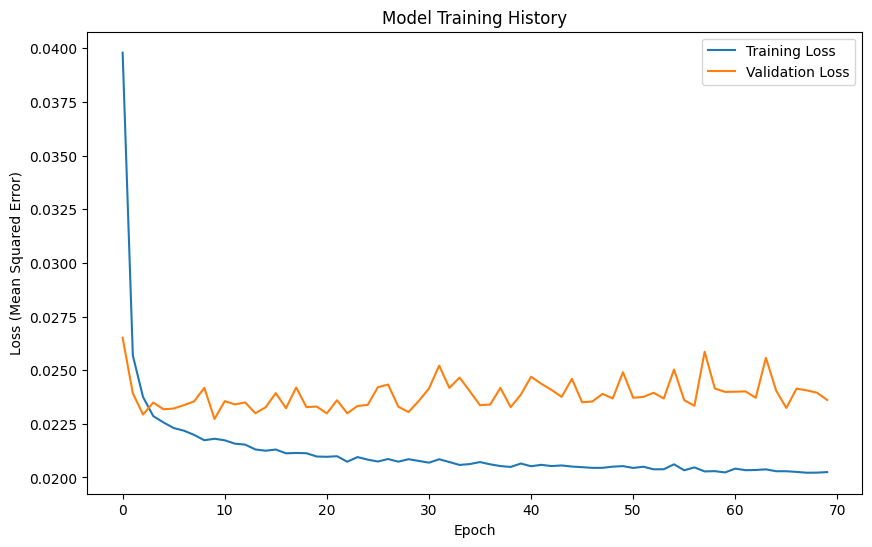

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()

--- Comprehensive Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): 17.83
Mean Absolute Error (MAE): 13.19
R-squared (R²) Score: 0.802


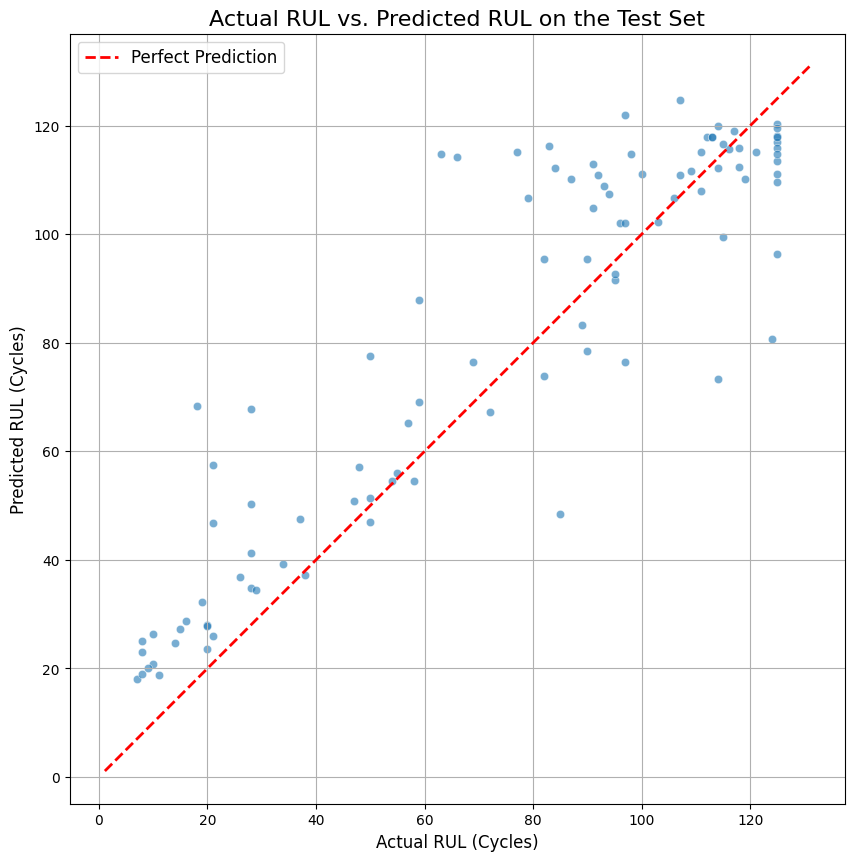

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. Calculate the Core Numerical Metrics ---

# We already have RMSE, let's just recall it
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_actual, y_pred)

# Calculate R-squared (R2) Score
r2 = r2_score(y_test_actual, y_pred)

print("--- Comprehensive Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²) Score: {r2:.3f}")


# --- 2. Create a Visual Evaluation Plot ---

# Create a scatter plot of the actual vs. predicted values
plt.figure(figsize=(10, 10))
sns.scatterplot(x=y_test_actual.flatten(), y=y_pred.flatten(), alpha=0.6)

# Add a "perfect prediction" line (y=x)
# We find the min and max of all values to set the line's limits
lims = [min(plt.gca().get_xlim()[0], plt.gca().get_ylim()[0]),
        max(plt.gca().get_xlim()[1], plt.gca().get_ylim()[1])]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')

plt.title('Actual RUL vs. Predicted RUL on the Test Set', fontsize=16)
plt.xlabel('Actual RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.axis('equal') # Ensures the x and y axes have the same scale
plt.show()